In [ ]:
%pip install -r ../requirements.txt

In [3]:
from pathlib import Path
import sys
import os
# Папка, где лежит ноутбук 
nb_dir = Path(os.getcwd()).resolve()
print("NB_DIR:", nb_dir)


# Корень проекта = родительская папка 
project_root = nb_dir.parent
print("PROJECT_ROOT:", project_root)

# Добавляем папку ноутбука 
if str(nb_dir) not in sys.path:
    sys.path.insert(0, str(nb_dir))

# Добавляем корень проекта 
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

NB_DIR: /home/daria/github_HiddenMatter/notebooks
PROJECT_ROOT: /home/daria/github_HiddenMatter


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier

from modules.pca import plot_pca
from modules.tsne import plot_tsne
from modules.umap import plot_umap
from modules.alpha_div import plot_shannon

Download tables of results from **Kraken**  `species_abundance`  
Make a taxon an index  
Join tables by taxon

In [5]:
df_il = pd.read_csv('../data/kraken_il_species_abundance.tsv', sep='\t')
df_he = pd.read_csv('../data/kraken_he_species_abundance.tsv', sep='\t')
df_he = df_he.set_index("taxon")
df_il = df_il.set_index('taxon')
df_all = pd.concat([df_il, df_he], axis=1).fillna(0)

Create metadata with sample group 

In [6]:
meta_il = pd.DataFrame({'sample': df_il.columns, 'group': 'disease'})
meta_he = pd.DataFrame({'sample': df_he.columns, 'group': 'healthy'})
meta = pd.concat([meta_il, meta_he], ignore_index=True)
meta = meta.set_index('sample')

Converting the number of reads to a relative abundance in the sample

In [7]:
df_rel = df_all.div(df_all.sum(axis=0), axis=1) 

Create top taxa  
Group by healthy/disease.  
For average abundance by group

In [9]:
top_taxa = df_rel.sum(axis=1).sort_values(ascending=False).head(10).index
df_top = df_rel.loc[top_taxa]
other = 1 - df_top.sum(axis=0)
df_top.loc["Other"] = other
df_top_t = df_top.T
df_top_t["group"] = meta["group"]
grouped_top = df_top_t.groupby("group").mean()
grouped_top = grouped_top.drop(columns="group", errors="ignore")

Plot for Mean relative abundance

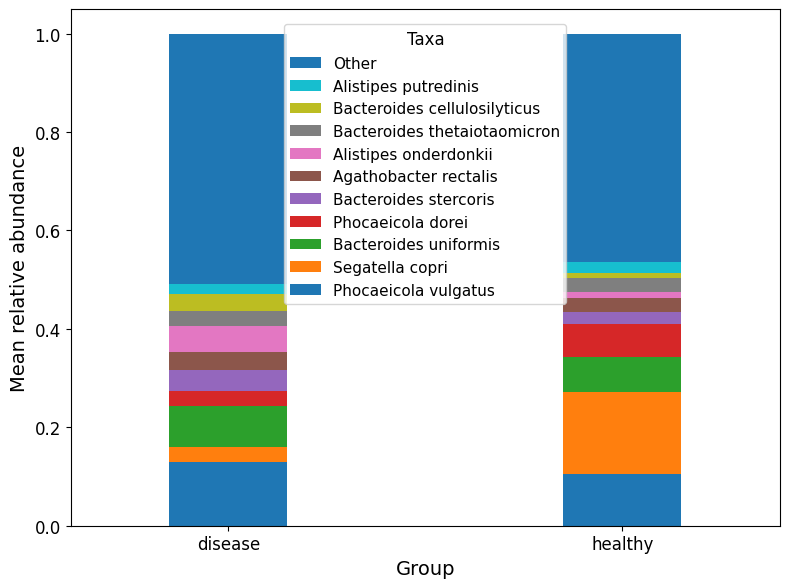

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

grouped_top.plot(kind="bar", stacked=True, ax=ax, width=0.3)

ax.set_ylabel("Mean relative abundance", fontsize=14)
ax.set_xlabel("Group", fontsize=14)

ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    bbox_to_anchor=(0.5, 0.7),
    loc="center",
    fontsize=11,
    title="Taxa",
    title_fontsize=12
)

plt.tight_layout()
plt.savefig('../results/mean_rel_abund10_kraken.png', dpi=300)
plt.show()

PCA

In [11]:
df_rel_t = df_rel.T

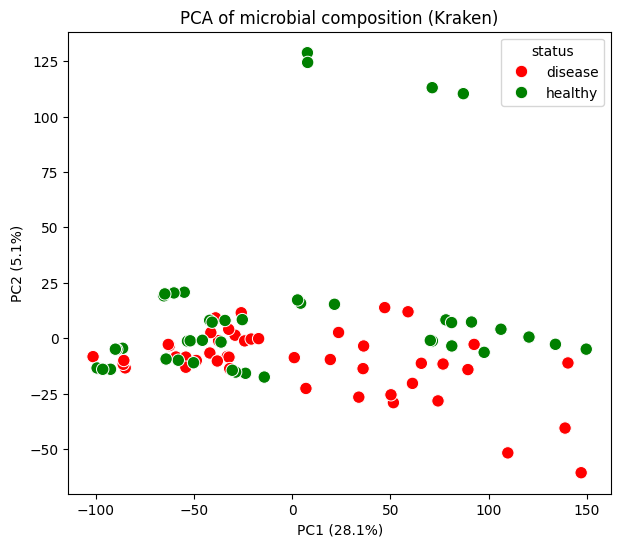

In [12]:
pca_df, pca = plot_pca(df_rel_t, meta, method="Kraken")

t-SNE

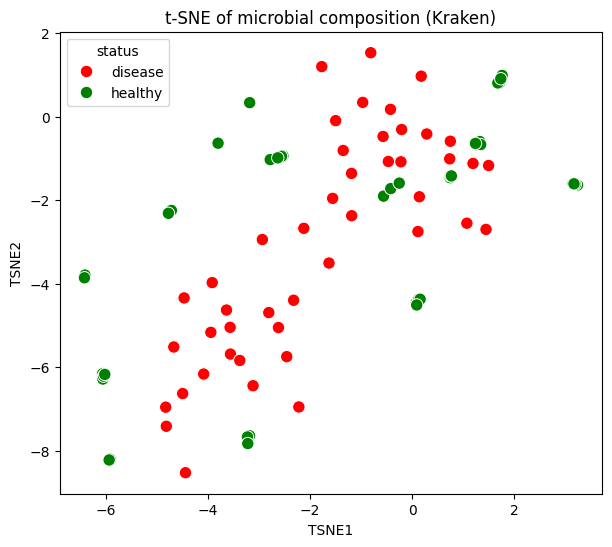

In [13]:
df_tsne, tsne = plot_tsne(df_rel_t, meta, method="Kraken")

UMAP

/home/daria/github_HiddenMatter/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


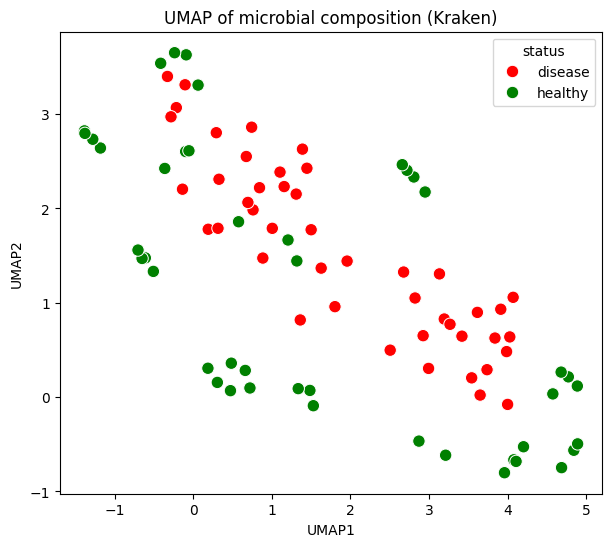

In [14]:
df_umap, umap = plot_umap(df_rel_t, meta, method="Kraken")

Alpha diversity

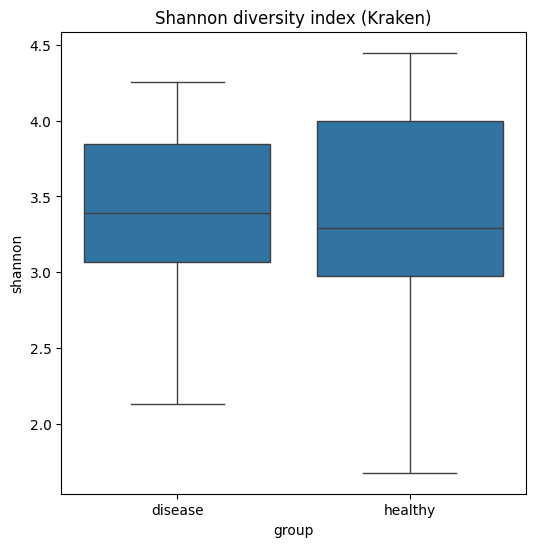

In [16]:
shannon_df = plot_shannon(df_rel_t, meta, method="Kraken")

ML  
Logistic regression

In [17]:
# Preprocessing and filtration

X = df_rel_t.copy()
y = meta["group"]
X = X.loc[y.index]
prevalence = (X > 0).mean(axis=0)
X = X.loc[:, prevalence >= 0.10]
mean_abundance = X.mean(axis=0)
X = X.loc[:, mean_abundance >= 1e-5]

# CLR transformation

def clr_transform(df, pseudocount=1e-6):
    X_pc = df + pseudocount
    log_X = np.log(X_pc)
    clr = log_X.sub(log_X.mean(axis=1), axis=0)
    return clr

X_clr = clr_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clr,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        l1_ratio=0.5, 
        C=1.0, 
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9, 1.0]
}

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best params: {'model__C': 0.01, 'model__l1_ratio': 0.1}
Best CV ROC-AUC: 1.0


In [21]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

     disease       1.00      1.00      1.00         9
     healthy       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Test ROC-AUC: 1.0
Confusion matrix:
[[9 0]
 [0 9]]


In [22]:
# Importance taxons

coef = best_model.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "taxon": X_clr.columns,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

importance.head(30)

,taxon,coef,abs_coef
715,Diaphorobacter ruginosibacter,0.113274,0.113274
728,Neptuniibacter halophilus,0.103629,0.103629
517,Mycobacterium canetti,0.097223,0.097223
577,Bdellovibrio bacteriovorus,0.093740,0.093740
727,Xanthomonas euvesicatoria,0.088968,0.088968
734,Yersinia similis,0.085560,0.085560
733,Chlamydia psittaci,0.083846,0.083846
198,Ectopseudomonas guguanensis,-0.050775,0.050775
361,Ectopseudomonas hydrolytica,-0.050186,0.050186
702,Bacillus velezensis,0.042643,0.042643


Random Forest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [2, 3],
    "min_samples_leaf": [20, 50],
    "min_samples_split": [50, 100],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)

In [24]:
print('Best params', grid.best_params_)
print("Classification report")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params {'class_weight': 'balanced', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 50, 'n_estimators': 300}
Classification report
              precision    recall  f1-score   support

     disease       1.00      1.00      1.00         9
     healthy       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

[[9 0]
 [0 9]]


In [25]:
feature_counts = pd.Series(0, index=X.columns, dtype=int)

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

for train_idx, test_idx in cv.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        **grid.best_params_,
        random_state=42
    )
    model.fit(X_tr, y_tr)

    importances = pd.Series(
        model.feature_importances_,
        index=X.columns
    )

    top_features = importances.sort_values(ascending=False).head(20).index
    feature_counts.loc[top_features] += 1

stable_features = feature_counts.sort_values(ascending=False).head(30)
print(stable_features)

taxon
Diaphorobacter ruginosibacter    100
Bdellovibrio bacteriovorus       100
Paenibacillus sp. DYY-L-2         94
Culoivirus americanus             94
Clostridium gelidum               88
Parafannyhessea umbonata          88
Petrimonas mucosa                 80
Granulicatella adiacens           80
Taranisvirus taranis              79
Faecalibaculum rodentium          74
Butyricimonas virosa              74
Xanthomonas euvesicatoria         70
Prevotella sp. E13-17             68
Sinanaerobacter sp. ZZT-01        61
Selenomonas ruminantium           61
Enterocloster lavalensis          59
Bacillus velezensis               58
Variovorax paradoxus              45
Eggerthella sp. YY7918            44
Sodaliphilus pleomorphus          38
Bacteroides pyogenes              35
Chlamydia psittaci                30
Lactococcus lactis                27
Prevotella herbatica              25
Eisenbergiella porci              24
Neptuniibacter halophilus         20
Kingevirus communis             

In [26]:
y_pred = model.predict(X_test)

In [27]:
print("Classification report")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Classification report
              precision    recall  f1-score   support

     disease       1.00      1.00      1.00         9
     healthy       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

[[9 0]
 [0 9]]
